<a href="https://colab.research.google.com/github/Ivan8Garcia/Proyectos_MachineLearning/blob/main/AgenteIA_conLangGraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
 %pip install -U langchain
 %pip install -U langgraph
 %pip install -U google-generativeai
 %pip install -U langchain-google-genai
 %pip install -U langchain-community
 %pip install arxiv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.6
    Uninstalling langgraph-1.2.6:
      Successfully uninstalled langgraph-1.2.6
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires re

In [2]:
import os
import google.generativeai as genai
from google.colab import userdata

api_key = userdata.get('Gemini_API_Key')
os.environ['GOOGLE_API_KEY'] = api_key
genai.configure(api_key=api_key)

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
llm= ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [5]:
from langchain_core.output_parsers import StrOutputParser


In [6]:
cadena= modelo_de_prompt | llm | StrOutputParser()

NameError: name 'modelo_de_prompt' is not defined

In [ ]:
respuesta= cadena.invoke({"tema":"educación"})



In [ ]:
print(respuesta)

In [7]:
#Tavily es como gemini para obtener APIS
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
import os

/tmp/ipykernel_2731/771142700.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


In [8]:
#entre parentesis "tavily", es el nombre propio que le otorgamos en secrets(se puede modificar dependiendo de como lo pongamos)
os.environ["TAVILY_API_KEY"]= userdata.get('tavily')

In [9]:
@tool
def busca_web(query:str)-> list:
  """Realiza una busqueda en la web sobre un tema especifico"""

  tavily_search= TavilySearchResults(
      max_results=2,
      search_depth="advanced",
      max_tokens=1000
  )

  resultado_busca= tavily_search.invoke(query)
  return resultado_busca

In [10]:
busca_web.invoke("impacto de la inteligencia artificial en la educación")

/tmp/ipykernel_2731/2895667095.py:5: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search= TavilySearchResults(


[{'title': 'El impacto de la inteligencia artificial en la educación y en la docencia - Universidad ORT Uruguay',
  'url': 'https://ie.ort.edu.uy/blog/el-impacto-de-la-inteligencia-artificial-en-la-educacion-y-en-la-docencia',
  'content': 'La inteligencia artificial en la educación contribuye al avance de cada estudiante a su ritmo, así como al trabajo en áreas específicas. Especialmente, en aquellas en las que se encuentran en proceso y aún son deficitarias.\n\nEstas tareas realizadas por la inteligencia artificial optimizan los tiempos del docente (tan valorados y ansiados). En consecuencia, pueden redirigir ese tiempo al desarrollo de propuestas más interactivas, centradas en la discusión y en la generación de procesos reflexivos, y de construcción individual y colectiva. [...] De la mano de la personalización, otra ventaja de la inteligencia artificial en la educación está dada por las posibilidades de accesibilidad a esos entornos personalizados de aprendizaje desde cualquier sit

In [18]:
tools = [busca_web]

In [19]:
llm_con_herramienta =llm.bind(tools=tools)

In [11]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [20]:
modelo_de_prompt = PromptTemplate(
    template= "Usando solo las tools disponibles, dime cuales son los impactos de la inteligencia artificial en el area de {tema}.",
    input_variables=["tema"]
)
cadena= modelo_de_prompt | llm_con_herramienta | StrOutputParser()

In [ ]:
respuesta= cadena.invoke({"tema":"educación"})

In [ ]:
prompt="Usando solo las tools disponibles, dime cuales son los impactos de la inteligencia artificial en el area de {tema}."

In [ ]:
respuesta= llm_con_herramienta.invoke(prompt)

In [ ]:
print(respuesta)

In [15]:
from langgraph.prebuilt import create_react_agent

In [16]:
from langchain.agents import create_agent

In [13]:
system_prompt= """
Actua como un asistente util y especializado en investigacion.
Utiliza las herramientas proporcionadas para responder a  las preguntas del usuario.

Herramientas disponibles:
-busca_web: realiza busquedas en la web y devuelve enlances y resumenes.

Siempre que el usuario pregunte sobre un tema especifico:
1. Usa la herramienta busca_web.
2. Analiza los resultados.
3. Devuelve una respuesta clara.
4. incluye los enlaces de las fuentes utilizadas.
"""

In [21]:
agente_web= create_react_agent(
    model=llm,
    tools=tools,
    prompt=system_prompt

)

/tmp/ipykernel_2731/3483719873.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web= create_react_agent(


In [ ]:
resultado= agente_web.invoke({
    "messages":[
        ("user", "Cuales son los impactos de la IA en la educacion")
    ]
})

In [ ]:
resultado

In [22]:
%pip install arxiv

In [23]:
from langchain_community.tools.arxiv.tool import ArxivQueryRun

In [24]:
tool_cientifica= ArxivQueryRun()

In [25]:
system_prompt2= """
Actua como un asistente util y especializado en investigacion.
Utiliza las herramientas proporcionadas para responder a  las preguntas del usuario.

Tool cientifica: Retorna resultados de una busqueda en arXiv.

Cuando el usuario pregunte sobre un tema especifico, usa tool_cientifica y devuelve los titulos de los articulos
"""

In [26]:
agente_cientifico= create_react_agent(
    model=llm,
    tools=[tool_cientifica],
    prompt=system_prompt2
)

/tmp/ipykernel_2731/1865283939.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_cientifico= create_react_agent(


In [30]:
resultado= agente_cientifico.invoke({
    "messages":[
        ("user", "AI impact in education")
    ]
})

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 35.330241478s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [ ]:
resultado

In [28]:
from typing import TypedDict

In [31]:
class AgentState(TypedDict):
  user_query: str
  web_answer: str
  scientific_answer: str
  final_answer: str

In [32]:
def funcion_agente_web(state: AgentState)-> dict:
  """
  Funcion que ejecuta un agente al estilo ReAct que realiza una busqueda en la web sobre un termino especifico.

  Esta funcion toma el estado actual del agente (que contiene la pregunta del usuario) y crea un agente utilizando gemini y la herramienta Tavily,
  y retorna la respuesta del agente.

  Args:
    state (AgentState): Un diccionario que contiene la pregunta del usuario y respuesta del agente .

  Returns:
      str: La respuesta del agente.
  """

  system_prompt= """
  Actua como un asistente util.
  Usa las herramientas proporcionadas para responder a las preguntas del usuario.

  -busca_web: retorna resultados en la web.

  cuando el usuario pregunte sobre un tema especifico, usa busca_web y devuelve enlaces en la respuesta
  """

  agente_web= create_react_agent(
      model=llm,
      tools=tools,
      prompt=system_prompt
  )

  resultado= agente_web.invoke({
      "messages":[("user", state["user_query"])]
  })

  respuesta_final= resultado["messages"][-1].content
  return {"web_answer":respuesta_final}

  return resultado


In [33]:
def funcion_agente_cientifico(state: AgentState)-> dict:
  """
  Funcion que ejecuta un agente al estilo ReAct que realiza una busqueda en arXiv sobre un termino especifico.

  Esta funcion toma el estado actual del agente (que contiene la pregunta del usuario) y crea un agente utilizando gemini y la herramienta Arxiv,
  y retorna la respuesta del agente.

  Args:
    state (AgentState): Un diccionario que contiene la pregunta del usuario y respuesta del agente .

  Returns:
      str: La respuesta del agente.
  """

  system_prompt= """
  Actua como un asistente util.
  Usa las herramientas proporcionadas para responder a las preguntas del usuario.

  -tool_cientifica: retorna resultados de una busqueda en arXiv.

  cuando el usuario pregunte sobre un tema especifico, usa tool_cientifica y devuelve los titulos de los articulos
  """


  agente_cientifico= create_react_agent(
      model=llm,
      tools=[tool_cientifica],
      prompt=system_prompt
  )

  resultado= agente_cientifico.invoke({
      "messages":[("user", state["user_query"])]
  })

  respuesta_final= resultado["messages"][-1].content
  return {"scientific_answer":respuesta_final}



In [34]:
from langgraph.graph import START, StateGraph, END

In [35]:
workflow= StateGraph(AgentState)


In [36]:
workflow.add_node("agente_web",funcion_agente_web)
workflow.add_edge(START, "agente_web")
workflow.add_edge("agente_web", END)

In [37]:
app= workflow.compile()

In [38]:
from IPython.display import Image, display

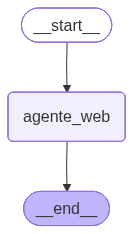

In [39]:
Image(app.get_graph().draw_mermaid_png())

In [40]:
resultado= app.invoke({"user_query":"Cual es el impacto de la inteligencia artificial en la medicina"})

/tmp/ipykernel_2731/604810774.py:24: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web= create_react_agent(


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 28.90577401s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url'

In [ ]:
print(resultado["web_answer"])

In [43]:
def supervisor_node(state:AgentState)-> dict:
  """
  combina los resultados de los agentes web y cientificos y formatea la respuesta final.

  Args:
    state (AgentState): El estado actual del agente que contiene web_answer y scientific_answer.

  Returns:
      dict: Un diccionario que contiene la respuesta final combinada y formateada.
  """
web_results= state.get("web_answer", "No se realizó busqueda web.")
scientific_results= state.get("scientific_answer", "No se realizó busqueda científica.")

final_answer= "## Resultados combinados de busqueda\n\n"
final_answer += "### Resultados desde la web\n\n" + web_results + "\n\n"
final_answer += "### Articulos cientificos\n\n" + scientific_results + "\n\n"

return {"final_answer": final_answer}





NameError: name 'state' is not defined

In [44]:
workflow= StateGraph(AgentState)

In [45]:
workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

In [46]:
workflow.add_edge(START, "web_search")
workflow.add_edge("web_search", "scientific_search")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)

In [47]:
app=workflow.compile()

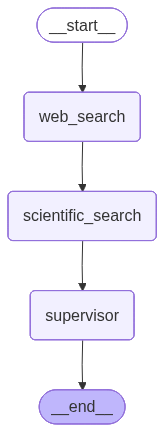

In [48]:
Image(app.get_graph().draw_mermaid_png())

In [50]:
resultado= app.invoke({"user_query": "Cual es el impacto de la IA en la medicina?"})
print(resultado["final_answer"])

/tmp/ipykernel_2731/604810774.py:24: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agente_web= create_react_agent(


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\nPlease retry in 11.824652905s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [51]:
def router_agent(state:AgentState)-> dict:
  router_prompt="""
  Eres un agente ruteador. tu tarea es decidir cual es mas apropiado poara responder la pregunta del usuario.

  pregunta del usuario: {user_query}

  puedes elegir entre las opciones:
  - web_search: usa esta opcion si la pregunta requiere una busqueda general en internet.
  - scientific_search: usa esta opcion si la pregunta requiere articulos cientificos.

  responde UNICAMENTE con el nombre de la opcion (web_search o scientific_search).
  """
  router_agent_instance= create_react_agent(
      model=llm,
      tools=[],
      prompt=router_prompt
  )

  response= router_agent_instance.invoke({
      "messages":[("user", state["user_query"])]
  })

  decision= response["messages"][-1].content.strip().lower()
  if decision == "web_search":
    return {"router_decicision" : "web_search"}
  elif decision == "scientific_search":
    return {"router_decicision" : "scientific_search"}

  # por defecto usamos web_search
  return{"router_decision": "web_search"}

In [52]:
workflow= StateGraph(AgentState)

In [53]:
workflow.add_node("router", router_agent)
workflow.add_node("web_search", funcion_agente_web)
workflow.add_node("scientific_search", funcion_agente_cientifico)
workflow.add_node("supervisor", supervisor_node)

In [54]:
workflow.add_edge(START, "router")
workflow.add_conditional_edges(
    "router",
    lambda state: state["router_decision"],
    {
        "web_search": "web_search",
        "scientific_search": "scientific_search"
    }
)
workflow.add_edge("web_search", "supervisor")
workflow.add_edge("scientific_search", "supervisor")
workflow.add_edge("supervisor", END)


In [55]:
app=workflow.compile()

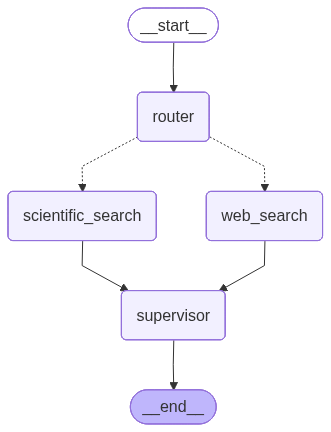

In [56]:
Image(app.get_graph().draw_mermaid_png())

In [58]:
resultado= app.invoke({
    "user_query": "Cual es el impacto de la IA en la educacion? usa solo fuentes de la web"
})
print(resultado["final_answer"])

/tmp/ipykernel_2731/1021491780.py:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  router_agent_instance= create_react_agent(


ChatGoogleGenerativeAIError: Error calling model 'gemini-2.0-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-2.0-flash\nPlease retry in 42.118073509s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url

In [59]:
import gradio as gr

In [60]:
def run_graph(user_query):
  """
  Ejecuta el LangGraph con la pregunta del usuario y devuelve la respuesta final.
  """

  result= app.invoke({"user_query": user_query})
  return result["final_answer"]


In [62]:
from IPython.core.display import Markdown
iface= gr.Interface(
    fn=run_graph,
    inputs=gr.Textbox(label="Escribe tu pregunta:"),
    outputs= gr.Markdown(label="Respuesta final"),
    title="Agente de busqueda inteligente",
    description= "Haz una pregunta y obten una respuesta usando fuentes web o cientificas"
)

In [63]:
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://62c9242049b367c736.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
